EKSPERYMENT: Train Walk_Fast → Detect Walk_Slow

  Train (Fast S1):       (179, 100, 26, 3)
  Val (Fast S1):         (25, 100, 26, 3)
  Test Normal (Fast S2): (213, 100, 26, 3)
  Test Anomaly (Slow):   (416, 100, 26, 3)

  Input dim: 7800
  Train:  mean=0.000, std=1.000
  Val:    mean=0.070, std=1.039


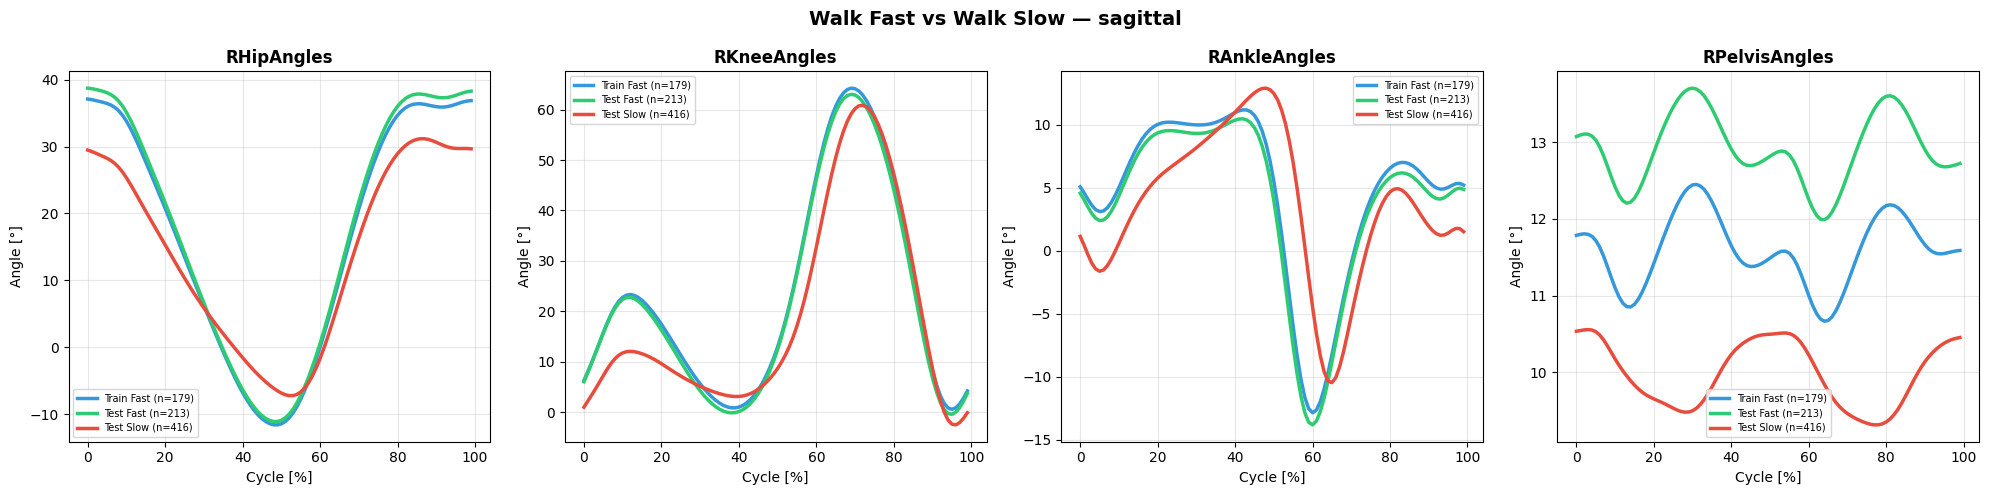


✅ Dane gotowe. Dalej: architektura + trening.


In [30]:
from pathlib import Path
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt


DATA_DIR = Path(r"E:/marcel.furs/Documents/Data_Run_Walk/Data_Run_Walk/EXPERIMENTS/exp_train_fast_detect_slow")

LATENT_DIM = 16
WIDTH_FIRST = 256
BETA_KL = 0.01
BATCH_SIZE = 32
DROPOUT = 0.2
LEARNING_RATE = 1e-3
EPOCHS = 1000
PATIENCE = 20

ANGLE_CHANNELS = [
    "LFootProgressAngles", "RFootProgressAngles",
    "LHipAngles",          "RHipAngles",
    "LKneeAngles",         "RKneeAngles",
    "LAnkleAngles",        "RAnkleAngles",
    "LForeFootAngles",     "RForeFootAngles",
    "LSpineAngles",        "RSpineAngles",
    "LShoulderAngles",     "RShoulderAngles",
    "LElbowAngles",        "RElbowAngles",
    "LWristAngles",        "RWristAngles",
    "LNeckAngles",         "RNeckAngles",
    "LPelvisAngles",       "RPelvisAngles",
    "LThoraxAngles",       "RThoraxAngles",
    "LHeadAngles",         "RHeadAngles",
]
NUM_JOINTS = len(ANGLE_CHANNELS)

# 1. Data
X_train = np.load(DATA_DIR / "X_train.npy")
X_val = np.load(DATA_DIR / "X_val.npy")
X_test_normal = np.load(DATA_DIR / "X_test_normal.npy")
X_test_anomaly = np.load(DATA_DIR / "X_test_anomaly.npy")

print(f"\n  Train (Fast S1):       {X_train.shape}")
print(f"  Val (Fast S1):         {X_val.shape}")
print(f"  Test Normal (Fast S2): {X_test_normal.shape}")
print(f"  Test Anomaly (Slow):   {X_test_anomaly.shape}")

# 2. PREPROCESSING
X_val_flat = X_val.reshape(X_val.shape[0], -1)
X_test_normal_flat = X_test_normal.reshape(X_test_normal.shape[0], -1)
X_test_anomaly_flat = X_test_anomaly.reshape(X_test_anomaly.shape[0], -1)

scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_train_flat)
X_val_norm = scaler.transform(X_val_flat)
X_test_normal_norm = scaler.transform(X_test_normal_flat)
X_test_anomaly_norm = scaler.transform(X_test_anomaly_flat)

input_dim = X_train_norm.shape[1]

print(f"\n  Input dim: {input_dim}")
print(f"  Train:  mean={X_train_norm.mean():.3f}, std={X_train_norm.std():.3f}")
print(f"  Val:    mean={X_val_norm.mean():.3f}, std={X_val_norm.std():.3f}")

In [31]:
# SETUP

In [32]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import backend as K

In [33]:
# Create a sampling layer

In [34]:
class Sampling(layers.Layer):
    """Reparameterization trick: z = μ + ε·σ,  ε∼N(0,I)."""
    
    def call(self, inputs):
        z_mean, z_logvar = inputs
        epsilon = tf.random.normal(tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_logvar) * epsilon

In [35]:
# Build the encoder (

In [36]:
encoder_inputs = keras.Input(shape=(input_dim,))
x = layers.Dense(WIDTH_FIRST, activation="relu")(encoder_inputs)
x = layers.Dropout(DROPOUT)(x)
x = layers.Dense(WIDTH_FIRST // 2, activation="relu")(x)
x = layers.Dropout(DROPOUT)(x)
z_mean = layers.Dense(LATENT_DIM, name="z_mean")(x)
z_log_var = layers.Dense(LATENT_DIM, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])
encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

print("\nENCODER:")
encoder.summary()


ENCODER:


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)    │ (None, 7800)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_10 (Dense)              │ (None, 256)               │       1,997,056 │ input_layer_4[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_8 (Dropout)           │ (None, 256)               │               0 │ dense_10[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_11 (Dense)              │ (None, 128)               │          32,896 │ dropout_8[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_9 (Dropout)           │ (None, 128)               │               0 │ dense_11[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ z_mean (Dense)                │ (None, 16)                │           2,064 │ dropout_9[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ z_log_var (Dense)             │ (None, 16)                │           2,064 │ dropout_9[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ sampling_2 (Sampling)         │ (None, 16)                │               0 │ z_mean[0][0],              │
│                               │                           │                 │ z_log_var[0][0]            │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 2,034,080 (7.76 MB)

 Trainable params: 2,034,080 (7.76 MB)

 Non-trainable params: 0 (0.00 B)

In [37]:
# Build the decoder

In [38]:
latent_input = keras.Input(shape=(LATENT_DIM,))
x = layers.Dense(WIDTH_FIRST // 2, activation="relu")(latent_input)
x = layers.Dropout(DROPOUT)(x)
x = layers.Dense(WIDTH_FIRST, activation="relu")(x)
x = layers.Dropout(DROPOUT)(x)
decoder_output = layers.Dense(input_dim, activation="linear")(x)
decoder = keras.Model(latent_input, decoder_output, name="decoder")

print("\nDecoder:")
decoder.summary()


Decoder:


Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)           │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 128)                 │           2,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_10 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 256)                 │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_11 (Dropout)                 │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 7800)                │       2,004,600 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,039,800 (7.78 MB)

 Trainable params: 2,039,800 (7.78 MB)

 Non-trainable params: 0 (0.00 B)

In [39]:
# Define the VAE

In [40]:
"""β-VAE: loss = MSE + β·KL."""
class VAE(keras.Model):
    def __init__(self, encoder, decoder, beta=BETA_KL, **kw):
        super().__init__(**kw)
        self.encoder     = encoder
        self.decoder     = decoder
        self.beta        = beta
        self.loss_tracker= keras.metrics.Mean(name="loss")
        self.mse_tracker = keras.metrics.Mean(name="mse")
        self.kl_tracker  = keras.metrics.Mean(name="kl")

    @property
    def metrics(self):          # <– Keras będzie to resetował co epokę
        return [self.loss_tracker, self.mse_tracker, self.kl_tracker]

    def call(self, x):
        _, _, z = self.encoder(x)
        return self.decoder(z)

    def train_step(self, x):
        with tf.GradientTape() as tape:
            mu, logvar, z = self.encoder(x, training=True)
            logvar = tf.clip_by_value(logvar, -10.0, 10.0)       #BEZ TEGO
            recon = self.decoder(z, training=True)
            mse = tf.reduce_mean(tf.square(x - recon), axis=1)
            kl  = -0.5 * tf.reduce_sum(1 + logvar - tf.square(mu) - tf.exp(logvar), axis=1)
            #loss = tf.reduce_mean(mse + self.beta * kl)
            loss = tf.reduce_mean(mse + self.beta * kl)

        grads = tape.gradient(loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.loss_tracker.update_state(loss)
        self.mse_tracker.update_state(tf.reduce_mean(mse))
        self.kl_tracker.update_state(tf.reduce_mean(kl))

        return {
            "loss": self.loss_tracker.result(),
            "mse":  self.mse_tracker.result(),
            "kl":   self.kl_tracker.result()
        }

    # val step (żeby działał val_loss)
    def test_step(self, x):
        mu, logvar, z = self.encoder(x, training=False)
        logvar = tf.clip_by_value(logvar, -10.0, 10.0)
        recon  = self.decoder(z, training=False)
        mse    = tf.reduce_mean(tf.square(x - recon), axis=1)
        kl     = -0.5 * tf.reduce_sum(1 + logvar - tf.square(mu) - tf.exp(logvar), axis=1)
        loss   = tf.reduce_mean(mse + self.beta * kl)
        self.loss_tracker.update_state(loss)
        self.mse_tracker.update_state(tf.reduce_mean(mse))
        self.kl_tracker.update_state(tf.reduce_mean(kl))
        return {
            "loss": self.loss_tracker.result(),
            "mse":  self.mse_tracker.result(),
            "kl":   self.kl_tracker.result()
        }




In [41]:
# Train the VAE


TRENING
  Train (Fast S1): 179 próbek
  Val   (Fast S1): 25 próbek
Epoch 1/1000
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step - kl: 128.3028 - loss: 2.3070 - mse: 1.0240 - val_kl: 58.3726 - val_loss: 1.6746 - val_mse: 1.0909
Epoch 2/1000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - kl: 423.6172 - loss: 5.2856 - mse: 1.0494 - val_kl: 66.1876 - val_loss: 1.7478 - val_mse: 1.0859
Epoch 3/1000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - kl: 317.1065 - loss: 12.4427 - mse: 9.2716 - val_kl: 63.1981 - val_loss: 1.7165 - val_mse: 1.0845
Epoch 4/1000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - kl: 314.5599 - loss: 4.1510 - mse: 1.0054 - val_kl: 66.8825 - val_loss: 1.7555 - val_mse: 1.0866
Epoch 5/1000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - kl: 245.7732 - loss: 3.5465 - mse: 1.0888 - val_kl: 49.2049 - val_loss: 1.5779 - val_mse: 1.0859
Epoch 6/1000
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - kl: 139.9818 - loss: 2.3978 - mse: 0.9979 - val_kl: 38.0751 - val_loss: 1.4662 - val_mse: 1.0855
Epoch 7/1000
6/6 ━━━━━━━━━━━━━━

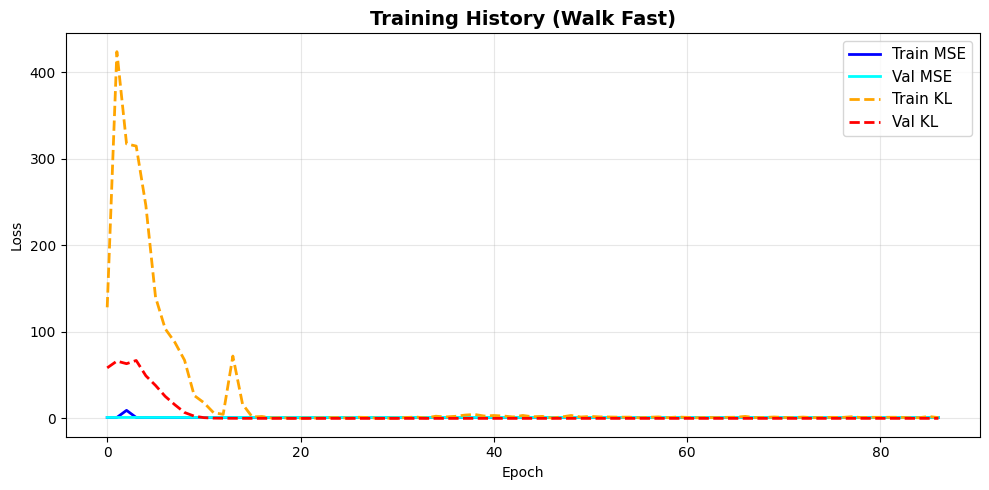

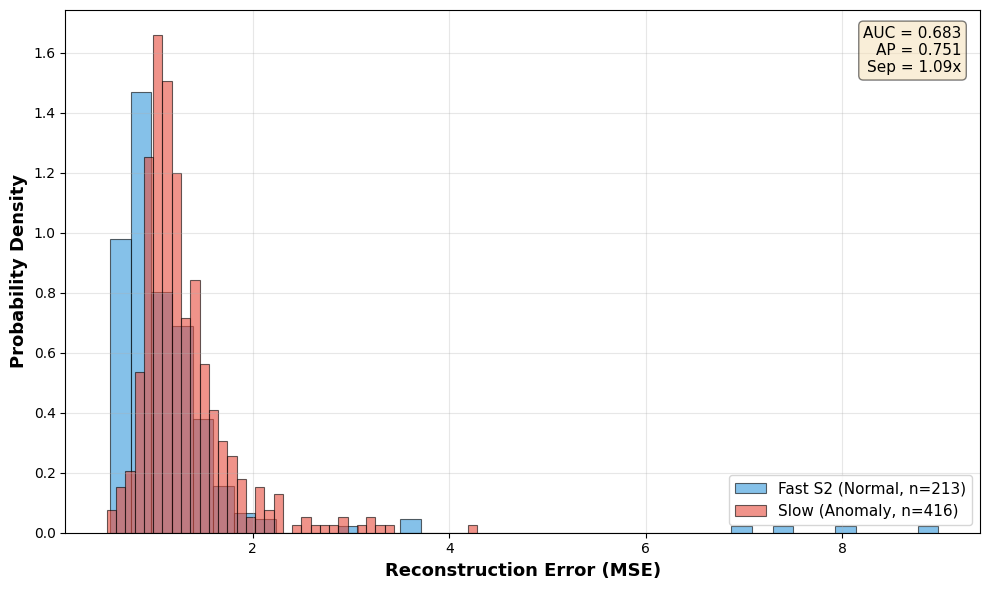

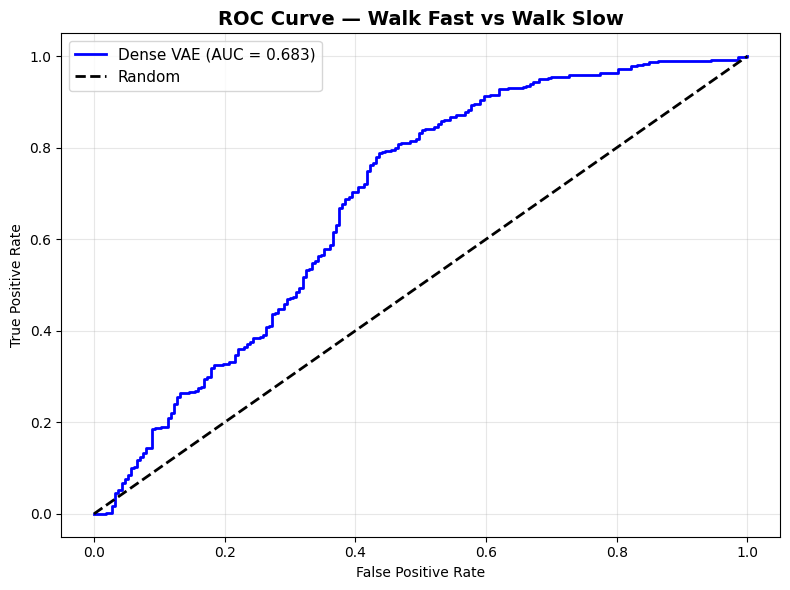

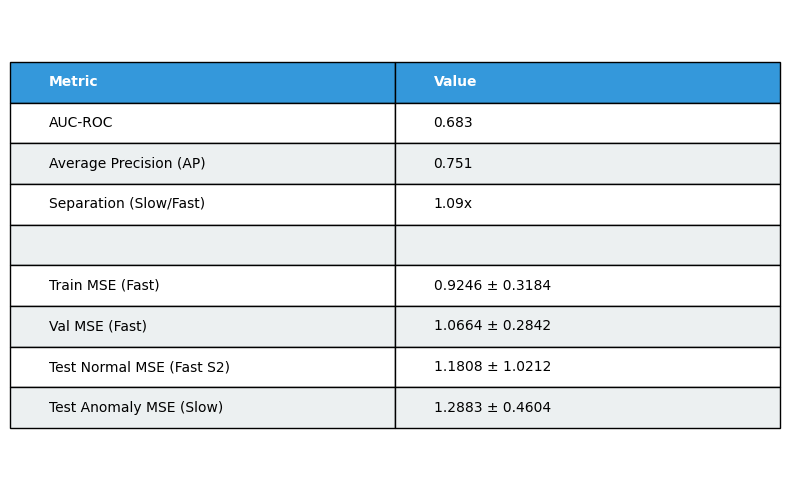


✅ EKSPERYMENT: Train Fast → Detect Slow


In [42]:
vae = VAE(encoder, decoder, beta=BETA_KL)
vae.compile(optimizer=keras.optimizers.Adam(LEARNING_RATE, clipnorm=1.0))

# 5. Train
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=PATIENCE,
    restore_best_weights=True,
    verbose=1
)

print(f"  Train (Fast S1): {X_train_norm.shape[0]} próbek")
print(f"  Val   (Fast S1): {X_val_norm.shape[0]} próbek")

history = vae.fit(
    X_train_norm,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_data=(X_val_norm, None),
    callbacks=[early_stop],
    verbose=1
)

# 6. Evaluation
def compute_mse(model, X):
    mu, logvar, z = model.encoder.predict(X, verbose=0)
    X_recon = model.decoder.predict(z, verbose=0)
    return np.mean((X - X_recon) ** 2, axis=1)


mse_train = compute_mse(vae, X_train_norm)
mse_val = compute_mse(vae, X_val_norm)
mse_test_normal = compute_mse(vae, X_test_normal_norm)
mse_test_anomaly = compute_mse(vae, X_test_anomaly_norm)

print(f"\n  Train (Fast S1):       {mse_train.mean():.6f} ± {mse_train.std():.6f}")
print(f"  Val   (Fast S1):       {mse_val.mean():.6f} ± {mse_val.std():.6f}")
print(f"  Test Normal (Fast S2): {mse_test_normal.mean():.6f} ± {mse_test_normal.std():.6f}")
print(f"  Test Anomaly (Slow):   {mse_test_anomaly.mean():.6f} ± {mse_test_anomaly.std():.6f}")

y_true = np.concatenate([
    np.zeros(len(mse_test_normal)),
    np.ones(len(mse_test_anomaly))
])
y_score = np.concatenate([mse_test_normal, mse_test_anomaly])

auc = roc_auc_score(y_true, y_score)
ap = average_precision_score(y_true, y_score)
separation = mse_test_anomaly.mean() / mse_test_normal.mean()
fpr, tpr, _ = roc_curve(y_true, y_score)

print(f"\n  AUC-ROC:            {auc:.3f}")
print(f"  Average Precision:  {ap:.3f}")
print(f"  Separation:         {separation:.2f}x")

# 7. plots
n_normal = len(mse_test_normal)
n_anomaly = len(mse_test_anomaly)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history.history["mse"], label="Train MSE", linewidth=2, color='blue')
ax.plot(history.history["val_mse"], label="Val MSE", linewidth=2, color='cyan')
ax.plot(history.history["kl"], label="Train KL", linewidth=2, linestyle='--', color='orange')
ax.plot(history.history["val_kl"], label="Val KL", linewidth=2, linestyle='--', color='red')
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training History (Walk Fast)", fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Histogram MSE
plt.figure(figsize=(10, 6))
plt.hist(mse_test_normal, bins=40, alpha=0.6, density=True,
         label=f'Fast S2 (Normal, n={n_normal})',
         color='#3498db', edgecolor='black', linewidth=0.8)
plt.hist(mse_test_anomaly, bins=40, alpha=0.6, density=True,
         label=f'Slow (Anomaly, n={n_anomaly})',
         color='#e74c3c', edgecolor='black', linewidth=0.8)
plt.xlabel('Reconstruction Error (MSE)', fontsize=13, fontweight='bold')
plt.ylabel('Probability Density', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
textstr = f'AUC = {auc:.3f}\nAP = {ap:.3f}\nSep = {separation:.2f}x'
plt.text(0.98, 0.97, textstr, transform=plt.gca().transAxes, fontsize=11,
         ha='right', va='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.tight_layout()
plt.savefig('figure_global_mse_fast_vs_slow.png', dpi=300, bbox_inches='tight')
plt.show()

# ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, color='blue', label=f'Dense VAE (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Walk Fast vs Walk Slow', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()